# Candidate Data in the U.S
## Spring 2026 CMSC320 Final Deliverable

**Contributions**

*   Alexis Tungcod  [Generated summaries and confusion matrix for data visualization, completed/edited exploratory analysis and intro]
*   Arnav Akella [part of eda, Conclusion]
*   Shiyam Rupeshkumar [Editing and adding to intro, Procuring and processing data set, Linear Regression, choosing how the regression tests are conducted, further processing before test 1,model 3, uploading final product]
*   Eva Griebl [Data Exploratory Data Analysis, Logistic Regression Classification, Ridge Regression Training ML]

**Table of Contents**

Our project follows the Data Lifecycle, from gathering and cleaning data to processing meaningful conclusions.

 Introduction: Why We Choose This Data

 Data Preparation: Cleaning & Preprocessing & Transformation

 Exploratory Data Analysis and Summary Statistics

 ML Algorithm Design/Development

 ML Algorithm Training and Test Data Analysis

 Data Visualizations

 Findings, Insights, Conclusions





## Introduction
The data set we are analyzing is the 2026 candidate summary dataset for financial information. This data set will include every candidate in the FEC database and any candidate that appears on a official state ballot

The politic scene in the U.S. is a very divisive subject for almost every resident. Looking through the dataset, we want to understand the relationship between the total funding and every other variable in the dataset. We'll also touch on the financial inequality among candidates, specific traits of the dataset, how party affiliation affects fundraising, and how incumbency status is related to other variables.

Almost all the focus is on the actions of Democrats and Republicans, but what about the smaller parties? Looking through our dataset, we want to understand the relationship and deeper details about all of the poltical participants in the country. How divided are these groups? What are their differences and what is the impact of support and resource distribution? By the end of our project we want to make suggestions to the audience and figure out ways to help all groups involved in politics to let their voices be heard.


## Data Preparation

An important aspect of our work is to make sure that the data is cleaned up and ready to be used for analysis. First, we have to successfully import the data.

In [250]:
%%capture
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kruskal
!pip install scikit-posthocs
import scikit_posthocs as sp

df = pd.read_csv("/content/sample_data/candidate_summary_2026.csv")
df.head(5)

# Data before it's cleaned
df_columns = list(df.columns.values)
display(df.info())

Shown below is a description of the columns in the dataset. Note how some columns are totals of others.

In [251]:
url = "https://www.fec.gov/campaign-finance-data/candidate-summary-file-description/"
table = pd.read_html(url)[0]
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('max_colwidth',None)
table = table.dropna(axis=0, how='all')
table

,0,1,2,3,4,5,6
0,Column name,Field name,Data type,Description,Range,Description,Example data
1,Link_Image,Link to candidate profile page,URl,NaN,NaN,Link to financial information and filings made directly by the candidate - mainly statements of candidacy for each election,https://www.fec.gov/data/candidate/P00000000/
2,Cand_Name,Candidate name,Character,Name of candidate,Max 90 characters,NaN,Martha Washington
3,Cand_Id,Candidate ID,Character,NaN,9 characters,"First character indicates office sought - H=House, S=Senate, P=Presidential. Characters 3 & 4 are the state abbreviation for Congressional candidates",NaN
4,Cand_Office,Candidate office,Text,office abbreviation,1 character,"H=House, S=Senate, P=President",h
5,Cand_Office_St,Candidate office state,Character,Postal abbreviation for state,2 characters,NaN,VA
6,Cand_Office_Dist,Candidate office district,Number,District number for House candidates,2 digits,NaN,01
7,Cand_Party_Affiliation,Candidate party affiliation,Character,Party abbreviation,3 characters,Dem=Democrat Rep=Republican full list of party affiliations,Non
8,Cand_Incumbent_Challenger_Open_Seat,Candidate incumbent challenger open seat,Character,Incumbent or challenger or open seat indicator,10 characters,I=incumbent; C=challenger; O=open seat (where no incumbent sought reelection),i
9,Total_Receipt,Total receipts,Currency,NaN,NaN,Sum of all receipt categories,10000.00


Now, we carry out the data cleaning process to make sure it is usable for analysis.


In [252]:
#to datetime
from datetime import datetime
df['Coverage_Start_Date'] = pd.to_datetime(df['Coverage_Start_Date'])
df['Coverage_End_Date'] = pd.to_datetime(df['Coverage_End_Date'])
#duplicates
df = df.drop_duplicates()

#columns without na values
#display(df.count()[df.count() == df.shape[0]])
#columns with na values | need to fill before converting
#display(df.count()[df.count() < df.shape[0]])
#to string + fillmissing values
missing_list =['Cand_Party_Affiliation','Cand_Incumbent_Challenger_Open_Seat','Cand_Street_1','Cand_Street_2','Cand_City','Cand_State']
for missing in missing_list:
  df[missing] = df[missing].fillna('UNKNOWN____').astype('string')
column_list = ['Link_Image','Cand_Name','Cand_Id','Cand_Office','Cand_Office_St','Cand_Id','Cand_Party_Affiliation','Cand_Incumbent_Challenger_Open_Seat','Cand_Street_1','Cand_Street_2','Cand_City','Cand_State']
for column in column_list:
  df[column] = df[column].astype('string')


#df_int_types = list(df.select_dtypes(include="int64"))
#df[df_int_types] = df[df_int_types].astype("float64")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3545 entries, 0 to 3544
Data columns (total 50 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   Link_Image                            3545 non-null   string        
 1   Cand_Name                             3545 non-null   string        
 2   Cand_Id                               3545 non-null   string        
 3   Cand_Office                           3545 non-null   string        
 4   Cand_Office_St                        3545 non-null   string        
 5   Cand_Office_Dist                      3517 non-null   float64       
 6   Cand_Party_Affiliation                3545 non-null   string        
 7   Cand_Incumbent_Challenger_Open_Seat   3545 non-null   string        
 8   Total_Receipt                         3545 non-null   float64       
 9   Total_Disbursement                    3545 non-null   float64       
 10  

## Exploratory Data Analysis (C)

**Conclusion 1:** Financial Inequality Among Candidates (Descriptive Statistics + Distribution Analysis)

Most campaign finance data is heavily right-skewed — a small number of candidates likely dominate total receipts. Using mean, median, skewness, and a Gini coefficient, you can quantify how unequal fundraising is across candidates.

**Plot idea:** A log-scale histogram of Total_Receipt, with vertical lines marking the mean and median to visually show the skew.


**Conclusion 2:** Party Affiliation Drives Fundraising Advantage (Hypothesis Testing — ANOVA or Mann-Whitney U)

You could test whether Total_Receipt or Individual_Itemized_Contribution differs significantly across Cand_Party_Affiliation (Democrat, Republican, third party). Since the data is likely non-normal, a Mann-Whitney U test (or Kruskal-Wallis for 3+ groups) is appropriate.

**Plot idea:** A grouped box plot or raincloud plot showing the distribution of fundraising by party, with significance brackets annotated.

**Conclusion 3:** Incumbency Status Predicts Cash on Hand (Correlation + Chi-Square or T-Test)

Incumbents typically have structural fundraising advantages. You could test whether Cand_Incumbent_Challenger_Open_Seat is associated with higher Cash_On_Hand_COP using a Welch's t-test or one-way ANOVA, and also examine the correlation between cash on hand and total disbursements.

**Plot idea:** A stacked bar chart showing average cash on hand by incumbency status, or a scatter plot of Cash_On_Hand_COP vs Total_Disbursement colored by incumbency category.

Here we display a histogram showing distributions between candidates of different parties. We only only covered the two main parties (Democrats and Republicans) with a third category being the others. We can see that the majority of candidates are Democratic with total 1792 entries. We will be using this concise dataframe in future conclusions below.

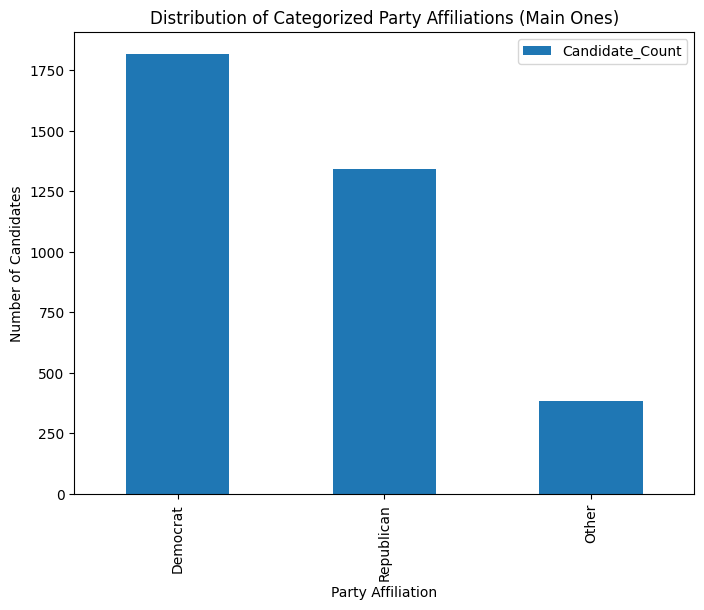

,Party,Candidate_Count
0,Democrat,1817
1,Republican,1344
2,Other,384


In [253]:
def get_party(affiliation):
    if affiliation in ['DEM', 'DFL']:
        return 'Democrat'
    elif affiliation in ['REP', 'GOP']:
        return 'Republican'
    else:
        return 'Other'

# added categorized party
df['Categorized_Party'] = df['Cand_Party_Affiliation'].apply(get_party)

#create new df
df_candidate_parties = df['Categorized_Party'].value_counts().reset_index()
df_candidate_parties.columns = ['Party', 'Candidate_Count']

plt.figure(figsize=(8, 6))
df_candidate_parties.plot(x='Party', y='Candidate_Count', kind='bar', ax=plt.gca())
plt.title('Distribution of Categorized Party Affiliations (Main Ones)')
plt.xlabel('Party Affiliation')
plt.ylabel('Number of Candidates')
plt.show()

display(df_candidate_parties)

# ***Conclusion 1:***
# Analyzing the relationship between the distribution of total receipts and number of candidates.

In [254]:
print(df['Total_Receipt'].mean())
print(df['Total_Receipt'].median())

413111.4774583921
4999.46


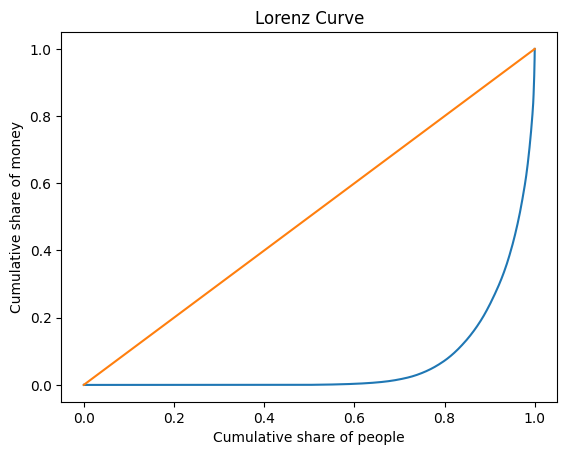

In [255]:
x = df["Total_Receipt"]
x = pd.to_numeric(x, errors="coerce")
x = x.dropna()
x = x.sort_values()

y = x.cumsum()
y = y / y.iloc[-1]
n = len(x)

p = np.arange(1, n+1) / n
y = np.insert(y.values, 0, 0)
p = np.insert(p, 0, 0)

plt.plot(p, y)
plt.plot([0,1], [0,1])  #equality line
plt.xlabel("Cumulative share of people")
plt.ylabel("Cumulative share of money")
plt.title("Lorenz Curve")

plt.show()

A Gini coefficient of about 0.87 shows there is a lot of inequality in campaign fundraising. This means that only a few candidates have most of the financial resources, while majority others raise much less. The Lorenz curve supports this finding because it is far from the line of perfect equality, which shows that most candidates contribute little to the total amount raised.

Group
Lowest 20%    3.404650e+05
20-40%        1.255029e+07
40-60%        2.180789e+07
60-80%        2.848075e+07
Top 20%       4.323140e+07
Name: Total_Receipt, dtype: float64


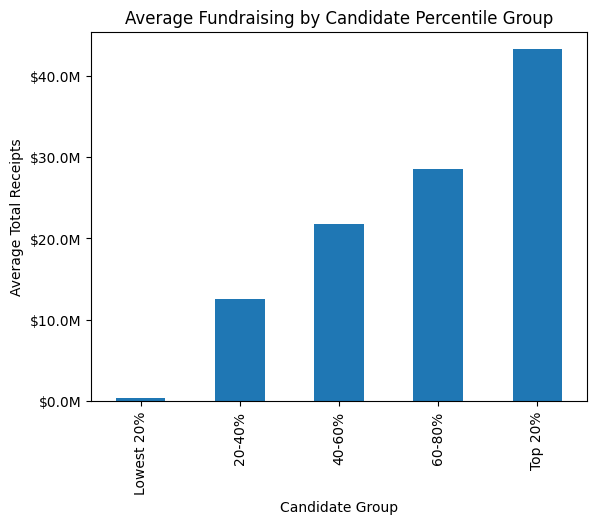

In [256]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
# Clean data
df_ = df.copy()
df_["Total_Receipt"] = pd.to_numeric(df_["Total_Receipt"], errors="coerce")
df_ = df_.dropna(subset=["Total_Receipt"])

 #Split into quartiles
df_ = df_.sort_values("Total_Receipt")
df_["Group"] = pd.cut(df_["Total_Receipt"], bins = 5, labels=[
    "Lowest 20%", "20-40%", "40-60%", "60-80%", "Top 20%"
])

warnings.simplefilter(action='ignore', category=FutureWarning)
group_means = df_.groupby("Group")["Total_Receipt"].mean()
warnings.simplefilter(action='default', category=FutureWarning)


print(group_means)

group_means.plot(kind="bar")

plt.title("Average Fundraising by Candidate Percentile Group")
plt.xlabel("Candidate Group")
plt.ylabel("Average Total Receipts")
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x/1_000_000:.1f}M'))
plt.show()

The percentile group analysis finds that average fundraising rises sharply as candidates move up the distribution. Lower- and middle-income groups raise modest amounts, but those in the top 20% raise much more. This shows a big gap between most candidates and the top fundraisers. We can see a left-skewed distribution between the average total recepits and the percentile of the candidate group.


# ***Conclusion 2:***
# Show where the three parties/groups medians differ, we run a Kruskal-Wallis test to find specifications.

𝐻0 : There is no effect of a candidates party on their total receipts

𝐻𝐴 : There is an effect of a candidates party on their total receipts.

Significance Level: 0.05

In [257]:
#  unique party affiliations from the main dataframe column adjusted before
party_groups = df['Categorized_Party'].unique()

grouped_data = {party: df[df['Categorized_Party'] == party]['Total_Receipt'].values for party in party_groups}

group_arrays = list(grouped_data.values())

# getting test statistics
h_statistic, p_value = kruskal(*group_arrays)

print(f"Kruskal-Wallis H statistic: {h_statistic}")
print(f"p-value: {p_value}")

# checking against significance value of 0.05
# if p value is significant we run a Dunn post hoc test
if p_value < 0.05:
  print("Reject the null hypothesis, the candidate party has an effect on their total receipts")

  dunn_test = sp.posthoc_dunn(df, val_col='Total_Receipt', group_col='Categorized_Party', p_adjust='holm')
  print(dunn_test)
elif p_value > 0.05:
  print("We fail reject the null hypothesis, the candidate party has no effect on their total receipts")

Kruskal-Wallis H statistic: 249.87935536747725
p-value: 5.487662720685134e-55
Reject the null hypothesis, the candidate party has an effect on their total receipts
                Democrat         Other    Republican
Democrat    1.000000e+00  1.977449e-51  8.549030e-01
Other       1.977449e-51  1.000000e+00  1.935609e-49
Republican  8.549030e-01  1.935609e-49  1.000000e+00


Based on the Kruskal-Wallis test we see that there differences exist between the Democratic, Republican, and Other parties total receipts. We run a post-hoc Dunn test in order to find where the differences are specifically and see that the "Other" group differs significantly from both Democrats and Republicans, while Democrats and Republicans do not significantly differ from each other.

It is quite common to see third-parties recieiving less funding and general support among the US population so these hypothesis tests make sense. With the dataframe containing three categories of parties, the third party averages could be seen as outliers compared to the other two since the Democratic and Republican parties dominating politics.

### Visualizing Party Affiliation and Total Receipts

To visually support **Conclusion 2: Party Affiliation Drives Fundraising Advantage**, and the results of the Kruskal-Wallis and Dunn post-hoc tests, we can use a box plot to compare the distribution of `Total_Receipt` (log-transformed for better visualization due to skewness) across the `Categorized_Party` groups.

/tmp/ipykernel_12578/2106226637.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Categorized_Party', y='Log_Total_Receipt', data=df_plot_party, palette='viridis')


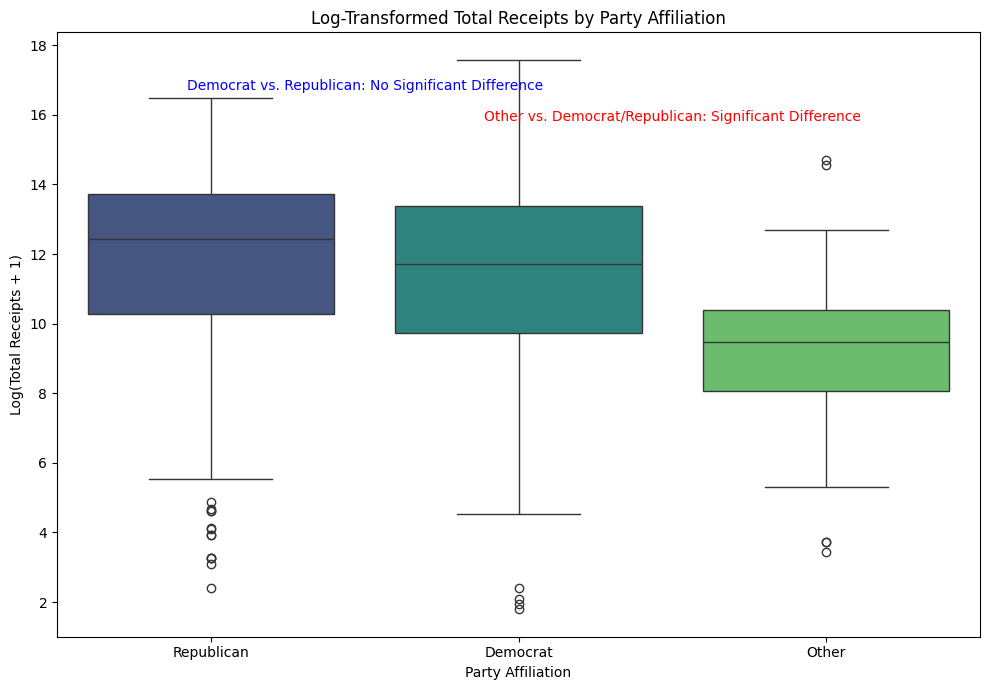

In [258]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Filter out rows where Total_Receipt is 0 as log transform would be problematic, and we're looking at distributions for those with receipts.
df_plot_party = df[df['Total_Receipt'] > 0].copy()

# Apply a log transformation to Total_Receipt for better visualization of skewed data
df_plot_party['Log_Total_Receipt'] = np.log1p(df_plot_party['Total_Receipt'])

plt.figure(figsize=(10, 7))
sns.boxplot(x='Categorized_Party', y='Log_Total_Receipt', data=df_plot_party, palette='viridis')
plt.title('Log-Transformed Total Receipts by Party Affiliation')
plt.xlabel('Party Affiliation')
plt.ylabel('Log(Total Receipts + 1)')

# Adding annotations for insights (manual for simplicity based on Dunn test)
plt.text(0.5, np.max(df_plot_party['Log_Total_Receipt']) * 0.95, 'Democrat vs. Republican: No Significant Difference', ha='center', fontsize=10, color='blue')
plt.text(1.5, np.max(df_plot_party['Log_Total_Receipt']) * 0.9, 'Other vs. Democrat/Republican: Significant Difference', ha='center', fontsize=10, color='red')

# Ensure all plot elements are visible
plt.tight_layout()
plt.show()

### Explanation of the Box Plot: Log-Transformed Total Receipts by Party Affiliation

**Purpose:** This box plot visualizes the distribution of log-transformed total campaign receipts (`Log_Total_Receipt`) for candidates grouped by their `Categorized_Party` affiliation. The log transformation helps to normalize the highly right-skewed `Total_Receipt` data, making comparisons between groups more interpretable.

**Elements:**
*   **X-axis (Party Affiliation):** Represents the three categorized political affiliations: 'Democrat', 'Other', and 'Republican'.
*   **Y-axis (Log(Total Receipts + 1)):** Shows the natural logarithm of `Total_Receipt` plus one. Adding one (`+1`) handles cases where `Total_Receipt` might be zero (though we filtered out zero values for this plot, `log1p` is robust). This scale compresses the large range of fundraising amounts, allowing for clearer visualization of central tendencies and spread.
*   **Boxes:** Each box represents the interquartile range (IQR) for a party, spanning from the 25th percentile (Q1) to the 75th percentile (Q3) of `Log_Total_Receipt`.
    *   The line inside each box indicates the median (50th percentile) `Log_Total_Receipt` for that party.
*   **Whiskers:** Extend from the boxes to show the range of the data, typically up to 1.5 times the IQR from Q1 and Q3. Data points outside this range are considered outliers.
*   **Outliers (Individual Points):** Shown as individual markers beyond the whiskers, representing receipts that are unusually high or low for their respective party.
*   **Annotations:** Text notes indicating the findings from the Dunn post-hoc test: "Democrat vs. Republican: No Significant Difference" and "Other vs. Democrat/Republican: Significant Difference".

**Insights:**
*   **Median Differences:** The median line for the 'Other' party is noticeably lower than those for 'Democrat' and 'Republican', indicating that candidates from 'Other' parties typically raise significantly less in campaign funds.
*   **Spread of Data:** The boxes for 'Democrat' and 'Republican' are generally positioned higher on the y-axis and show similar spreads, reinforcing the idea that their fundraising distributions are comparable.
*   **Kruskal-Wallis and Dunn Test Support:** This visual confirms the statistical findings that there's a significant difference in fundraising between 'Other' parties and the two major parties, while the major parties themselves do not show a statistically significant difference in their `Total_Receipt` distributions. This highlights the substantial financial disadvantage faced by third-party candidates.

 # ***Conclusion 3:***
 # Conduct a one-way ANOVA test comparing Cash_On_Hand_COP across Incumbents, Challengers, and Open-Seat candidates.

𝐻0 : There is no significant difference in Cash on Hand between candidate statuses.

𝐻𝑎 : There is a significant difference in Cash on Hand between candidate statuses.

ANOVA F-statistic: 348.5310666114004
p-value: 2.599917727112039e-198


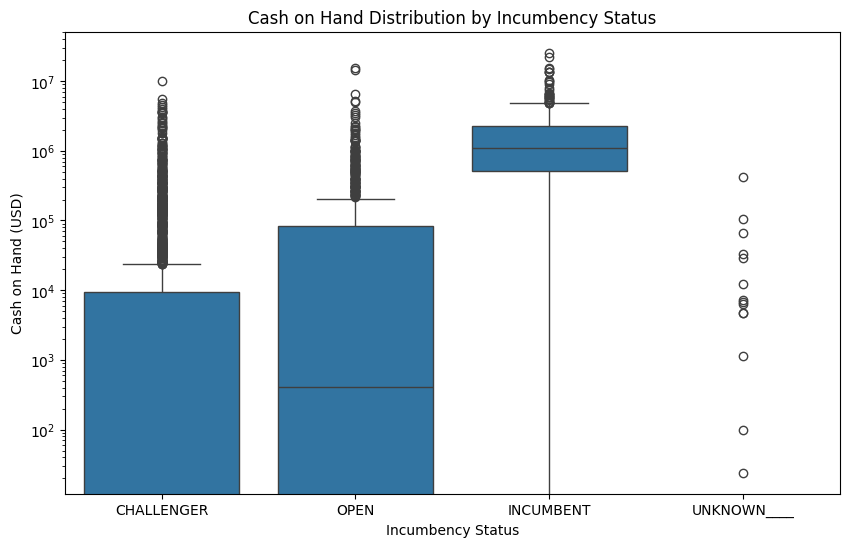

In [259]:
# Import the necessary packages
from scipy.stats import f_oneway
import seaborn as sns

# Filter out rows with missing values
df_anova = df.dropna(subset=['Cash_On_Hand_COP', 'Cand_Incumbent_Challenger_Open_Seat'])

# Group data by incumbency status
groups = df_anova.groupby('Cand_Incumbent_Challenger_Open_Seat')['Cash_On_Hand_COP'].apply(list)

# Perform the One-Way ANOVA Test on the groups
f_stat, p_val = f_oneway(*groups)
print(f'ANOVA F-statistic: {f_stat}')
print(f'p-value: {p_val}')

# Visualize the data via boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cand_Incumbent_Challenger_Open_Seat', y='Cash_On_Hand_COP', data=df_anova)
plt.yscale('log')
plt.title('Cash on Hand Distribution by Incumbency Status')
plt.xlabel('Incumbency Status')
plt.ylabel('Cash on Hand (USD)')
plt.show()

Based on the results from the one-way ANOVA test, we reject the null hypothesis and conclude that there is a significant difference in Cash on Hand between the different candidate status groups. It shows that differences in cash on hand are not due to random chance. The visualization shown above reinforce these results. The boxplot shows that incumbents consistently maintain higher median and upper-quartile cash on hand compared to other candidate types.

## **Primary Analysis**

### Machine Learning Approach: Regression

Based on the exploratory data analysis performed earlier, we observed several important patterns in the campaign finance dataset:

Campaign fundraising is heavily right-skewed, with a small number of candidates raising the majority of funds.
Democratic and Republican candidates significantly outperform third-party candidates in total fundraising.
Incumbent candidates generally maintain higher cash-on-hand values than challengers or open-seat candidates.

These findings suggest that candidate characteristics such as political affiliation, incumbency status, and office type may strongly influence campaign fundraising outcomes. To further investigate these relationships, we apply multiple machine learning techniques inspired by the regression and classification methods developed throughout Homework 5.

We organize our machine learning analysis into three separate models:

1 - only non financial features focus on whether they have any funding at all(yes they have funding no they don't result(use logistic regression))

2 - only non financial features, only use non 0 total receipt rows, focus on the amount of funding they get as an answer(ridge regression?)

3 - all features not directly in the formula and then reduce dimensionality after(lasso regression?)


Each model answers a different research question related to campaign finance inequality and political fundraising success.





Importantly, we want to avoid using columns directly related to the formula of total_receipt. Otherwise, this whole endeavor of using regression would be useless. Usually the description provided in the 'table' variable gives us the formula for any total variables, but the description for total_receipt just repeats its name. Additionaly, from a few attempts at trial and error the formula is not immediately obvious. So, now we must employ an actual method to find this formula.  

Linear Regression is perfect for this task as we know that the formula for total receipts must be simple addition. Any column with the phrase 'Sum of' in their column description are removed as not to cause overlap with their addends, two columns were also individually removed for being unrelated to money.  

In [260]:

df_l = df.copy()
table["Description"] = table[5].astype("string")
sum_cols = list(table[table["Description"].str.contains("Sum of")][0])

from sklearn.linear_model import LinearRegression

financial_cols = list(df.select_dtypes(include=["float64","int64"]).columns)
financial_cols = [x for x in financial_cols if x not in sum_cols] #https://stackoverflow.com/questions/3416401/removing-elements-from-a-list-containing-specific-characters
financial_cols.remove("Cand_Office_Dist")
financial_cols.remove("Cand_Zip")

df_l[financial_cols] = df_l[financial_cols].fillna(0)
df_l["Total_Receipt"] = df_l["Total_Receipt"].fillna(0)

X = df_l[financial_cols].fillna(0)
y = df_l["Total_Receipt"].fillna(0)
model = LinearRegression()
model.fit(X,y)
model.predict(X)
coef_df = pd.DataFrame({'features':financial_cols, 'coef':model.coef_})
total_receipt_formula = coef_df[coef_df["coef"].abs() > 0.001]

total_receipt_formula


,features,coef
2,Individual_Itemized_Contribution,0.999446
3,Individual_Unitemized_Contribution,0.999450
4,Other_Committee_Contribution,0.999444
5,Party_Committee_Contribution,0.999454
6,Cand_Contribution,0.999445
7,Transfer_From_Other_Auth_Committee,0.999449
8,Cand_Loan,0.999448
9,Other_Loan,0.999439
10,Offsets_To_Operating_Expenditure,0.999452
13,Other_Receipts,0.999448


We now validate our findings by comparing to the original receipts column.



In [261]:
df_validate = df_l.copy()
df_validate['validate_total_receipt'] = df_validate[total_receipt_formula['features']].sum(axis=1)
df_validate['validate_total_receipt'] = df_validate['Total_Receipt'] - df_validate['validate_total_receipt']
df_error = df_validate[df_validate['validate_total_receipt'].abs().round() != 0]
display(f"Accuracy :{round((1 - (len(df_error))/df.shape[0]),3)}")

original_df = df[df["Cand_Id"].isin(list(df_error["Cand_Id"]))]
number_of_na = original_df[total_receipt_formula['features']].isna().sum().sum()
display(f"# of NA values in the row :{int(number_of_na)} ")


'Accuracy :0.999'

'# of NA values in the row :0 '

With an accuracy of 0.999, it's safe to say our formula is indeed the right one.

Searching the unaltered df, we check every column used in our new formula to see if setting all missing values to 0 caused the 0.0001 error. This is not true so we can reasonably assume the errors were from the original dataset. This allows us to drop these rows in good conscience before continuing.

In [262]:
df_l = df[~df["Cand_Id"].isin(list(df_error['Cand_Id']))]

Now we can drop all directly related columns and drop all columns whose formulas contain already existing columns. We can continue dropping variables that are either too specific to matter or are clearly irrelevant to avoid the curse of dimensionality. We will refrain from dropping rows with na values just yet because different tests will have different features.

In [263]:
df_l = df_l.drop((total_receipt_formula['features']), axis= 1)
sum_cols.remove("Total_Receipt")
df_l = df_l.drop(((sum_cols)), axis= 1)
#party affiliation was dropped due to overlap with categorized party
irrelevant_features = ['Link_Image', 'Cand_Name', 'Coverage_End_Date','Cand_Street_1','Cand_Street_2','Coverage_Start_Date','Cand_Zip','Cand_Party_Affiliation',"Cand_Id"]
df_l = df_l.drop(irrelevant_features,axis=1)

As mentioned above in our exploratory data analysis, the total_receipt data is extremely right skewed so the regression analysis will be split into two.

The first will analyse what affects having any funding at all(will keep all values), and the second will analyze what affects the amount of funding(drop all rows with 0).

We will also split the features by whether they are a financial feature or not and reconduct the second regression test using them. It would be better not to combine them with the non-financial features as it's hard to tell whether or not total_receipts directly affect them in some way. They would also largely be useless for test 1 as candidates with 0 total_receipts most likely have 0 in all other financial categories.



In [264]:
financial_features = ['Cash_On_Hand_COP','Debt_Owed_By_Committee','Offsets_To_Fundraising',
 'Offsets_To_Leagal_Accounting',
 'Operating_Expenditure',
 'Exempt_Legal_Accounting_Disbursement',
 'Fundraising_Disbursement',
 'Transfer_To_Other_Auth_Committee',
 'Cand_Loan_Repayment',
 'Other_Loan_Repayment',
 'Individual_Refund',
 'Party_Committee_Refund',
 'Other_Committee_Refund',
 'Other_Disbursements',
 'Cash_On_Hand_BOP',
 'Debt_Owe_To_Committee']
other_features = [x for x in list(df_l.columns) if x not in financial_features]

df_l_anymoney = df_l[other_features].dropna()
display(df_l_anymoney.isna().sum())

df_l_anymoney = df_l_anymoney[df_l_anymoney['Total_Receipt']!= 0]
df_l_total_receipt = df_l_anymoney['Total_Receipt']
df_l_anymoney.drop("Total_Receipt",axis=1)

df_l_amount = df_l[other_features]
df_l_amount_financial = df_l.copy()

,0
Cand_Office,0
Cand_Office_St,0
Cand_Office_Dist,0
Cand_Incumbent_Challenger_Open_Seat,0
Total_Receipt,0
Cand_City,0
Cand_State,0
Categorized_Party,0


# **Model 1: Logisitic Regression Classification**
For our Logistic Regression Classification model we will be predicting whether a candidate is able to raise a large (meaningful)campaign funding.

Our target will be candidates who have raised more than $10,000 therefore classifying them as having large campaign funding.

This is a binary classification problem as we will categorize our candidates as one category (large campaign funding) or the other (not large campaign funding).

In [265]:
#Features Used Financially related features):
logistic_features = [
    "Categorized_Party","Cand_Office","Cand_Incumbent_Challenger_Open_Seat","Cand_State"
]

These features were chosen because they and financially related and we want to identify if the state of these features directly relates with the amount of campaign funding raised.

# Algorithm: *

In [266]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

import numpy as np
import pandas as pd

## *Helper Function*

In [267]:
random_state = 42
test_size = 0.2

def split_data(X, Y, test_size=test_size, random_state=random_state):
    X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=test_size,random_state=random_state
    )

    return X_train, X_test, Y_train, Y_test

In [268]:
df_logistic = df.copy()

df_logistic["Has_Funding"] = (df_logistic["Total_Receipt"] > 10000).astype(int)
logistic_features = [
    "Categorized_Party",
    "Cand_Office",
    "Cand_Incumbent_Challenger_Open_Seat",
    "Cand_State"
]

X_logistic = df_logistic[logistic_features]
Y_logistic = df_logistic["Has_Funding"]

In [269]:
X_logistic_train, X_logistic_test, Y_logistic_train, Y_logistic_test = split_data(
    X_logistic,
    Y_logistic
)
def fit_logistic_model(X_train, Y_train):

    categorical_features = list(X_train.columns)

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore"),
                categorical_features
            )
        ]
    )

    model = make_pipeline(
        preprocessor,
        LogisticRegression(max_iter=1000)
    )

    model.fit(X_train, Y_train)

    return model
logistic_model = fit_logistic_model(X_logistic_train,
    Y_logistic_train
)
def predict_logistic_data(model, X_train, X_test):

    Y_train_pred = model.predict(X_train)

    Y_test_pred = model.predict(X_test)

    return Y_train_pred, Y_test_pred
Y_logistic_train_pred, Y_logistic_test_pred = predict_logistic_data(
    logistic_model, X_logistic_train,
    X_logistic_test
)
def evaluate_logistic_model(
    Y_train,
    Y_train_pred, Y_test, Y_test_pred
):

    train_accuracy = accuracy_score(
        Y_train, Y_train_pred
    )

    test_accuracy = accuracy_score(
        Y_test,Y_test_pred
    )

    return train_accuracy, test_accuracy, logistic_train_accuracy
    logistic_test_accuracy = evaluate_logistic_model(
    Y_logistic_train,
    Y_logistic_train_pred,
    Y_logistic_test,
    Y_logistic_test_pred
)

print("Train Accuracy:", logistic_train_accuracy)
print("Test Accuracy:", logistic_test_accuracy)

Train Accuracy: 0.6971086036671368
Test Accuracy: 0.6671368124118476


The Logistic Regression model predicted if a candidate raised more than $10,000 using factors such as party, office type, incumbency, and state. Its training accuracy was 0.697, and its testing accuracy was 0.667. Because these scores are similar, the model is not overfitting as well as works consistently on new data.

The confusion matrix shows the model is better at finding candidates who do not raise much money than those who do. This result is expected because fundraising depends on many factors we did not include, such as name recognition or media coverage.

This model shows that political characteristics affect fundraising, but that there are addition factors that may weigh more heavily.

# Model 2. Ridge **Regression**

Ridge Regression will be used to predict the amount of money a candidate raises.

This is a regression problem because the target variable is continuous.

The exploratory data analysis showed that Total_Receipt is right-skewed. To reduce that, we apply a logarithmic transformation. Ridge Regression also helps limit overfitting when numerical variables are related.

In [270]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

In [271]:
df_ridge = df[df["Total_Receipt"] > 0].copy()
df_ridge["Log_Receipt"] = np.log1p(
    df_ridge["Total_Receipt"]
)
ridge_features = [
    "Categorized_Party",
    "Cand_Office",
    "Cand_Incumbent_Challenger_Open_Seat",
    "Cash_On_Hand_BOP",
    "Operating_Expenditure",
    "Debt_Owed_By_Committee"
]
X_ridge = df_ridge[ridge_features]
Y_ridge = df_ridge["Log_Receipt"]
X_ridge_train, X_ridge_test, Y_ridge_train, Y_ridge_test = split_data(
    X_ridge,
    Y_ridge,
)

In [272]:
def trainRidgeRegression(X_train, Y_train, X_test, Y_test):
  #group features to be used
    categorical_features = [
        "Categorized_Party","Cand_Office", "Cand_Incumbent_Challenger_Open_Seat"
    ]
    numeric_features = [
        "Cash_On_Hand_BOP",
        "Operating_Expenditure",
        "Debt_Owed_By_Committee"
    ]
    preprocessor = ColumnTransformer(
        transformers=[
            ("cat",
                OneHotEncoder(handle_unknown="ignore"),categorical_features),
            ("num",make_pipeline(SimpleImputer(strategy="median"), StandardScaler()),numeric_features)
        ]
    )
    model = make_pipeline(preprocessor, Ridge(alpha=1.0))
    model.fit(X_train, Y_train)
    #train model
    trainpredict = model.predict(X_train)
    testpredict = model.predict(X_test)

    msetrain = mean_squared_error(Y_train, trainpredict)
    msetest = mean_squared_error(Y_test, testpredict)
    train2 = r2_score(Y_train, trainpredict)
    test2 = r2_score(Y_test, testpredict)
  #display results
    print("MSE Train:", msetrain)
    print("MSE Test:", msetest)
    print("R2 Train:", train2)
    print("R2 Test:", test2)

    return model, msetrain, msetest, train2, test2

In [273]:
model_ridge, mse_ridge_train, mse_ridge_test, r2_ridge_train, r2_ridge_test = trainRidgeRegression(X_ridge_train,Y_ridge_train,X_ridge_test,Y_ridge_test)

MSE Train: 3.5867653025918647
MSE Test: 3.395589500366836
R2 Train: 0.40258899834957573
R2 Test: 0.4037705424263859


The Ridge Regression model predicted how much funding a candidate raises. It achieved an R² of 0.40 on both the training and test sets, explaining about 40% of the variation in fundraising amounts. Since the scores are almost the same, the model does not seem to be overfitting.

A 40% result is not very strong, but we are only using features such as party and incumbency status. Many other factors, such as name recognition or the political climate, are not included in our dataset. Overall, this is a decent starting point, but the model would improve with more features.



# Model 3. Ridge Regression


In [274]:
from sklearn.pipeline import Pipeline

df_ridge3 = df_l_amount_financial.copy()
#display(df_ridge3.isna().sum())
df_ridge3 = df_ridge3.drop(['Cand_Office_Dist','Cand_Office_St','Cand_City','Cand_State'], axis = 1) #27 missing values and too specific to be of use with the large amount of features about to be applied
df_ridge3 = df_ridge3.fillna(0) # 8 missing values in various financial columns
df_ridge3 = df_ridge3[df_ridge3["Total_Receipt"]>0]
y3 = df_ridge3["Total_Receipt"]
X3 = df_ridge3.drop("Total_Receipt", axis = 1)
df_ridge3["Categorized_Party"]  = df_ridge3["Categorized_Party"].astype("string")
categorical = list(X3.select_dtypes(include=['string']).columns)
financial = list(X3.select_dtypes(include=['float64','int64']).columns)

X_train3, X_test3, y_train3, y_test3 = train_test_split(X3,y3, test_size=0.2, train_size = 0.8, random_state = 777)



In [275]:

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

processor3 = ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown= 'ignore'), categorical),('fin',StandardScaler(),financial)])
ridge3 = Pipeline(steps=[('preprocessor',processor3),('ridge',Ridge(alpha=1.0))])

ridge3.fit(X_train3,y_train3)
y_pred3 = ridge3.predict(X_test3)
display('r2score')
display(r2_score(y_test3,y_pred3))
display('mean absolute error')

display(mean_absolute_error(y_test3,y_pred3))


'r2score'

0.9999743297964576

'mean absolute error'

2257.2570367904746

In [276]:
weights3 = pd.DataFrame({'feature':ridge3.named_steps['preprocessor'].get_feature_names_out(),'coeff':list(ridge3.named_steps['ridge'].coef_)})
weights3 = weights3[weights3['coeff'].abs()>0.01].round(3)
weights3

,feature,coeff
0,cat__Cand_Office_H,-346.641
1,cat__Cand_Office_P,-276.633
2,cat__Cand_Office_S,623.273
3,cat__Cand_Incumbent_Challenger_Open_Seat_CHALLENGER,-112.399
4,cat__Cand_Incumbent_Challenger_Open_Seat_INCUMBENT,109.462
5,cat__Cand_Incumbent_Challenger_Open_Seat_OPEN,651.668
6,cat__Cand_Incumbent_Challenger_Open_Seat_UNKNOWN____,-648.731
7,fin__Cash_On_Hand_COP,1567419.981
8,fin__Debt_Owed_By_Committee,353.929
11,fin__Operating_Expenditure,1159033.097


## Data Visualizations


### Confusion Matrix

To understand the performance of our Logistic Regression model, which predicts whether a candidate has "meaningful funding" (defined as `Total_Receipt` > $10,000), a Confusion Matrix is highly informative. It breaks down the model's predictions into four categories based on what the model predicts.

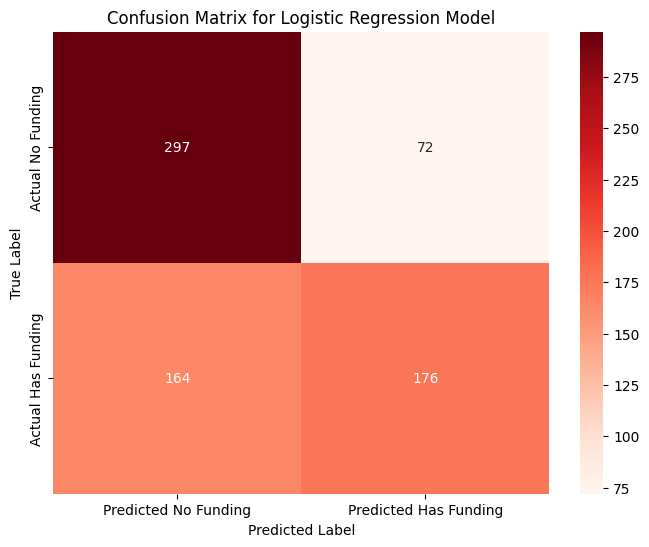

In [277]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# calculate the confusion matrix for the test set
conf_matrix = confusion_matrix(Y_logistic_test, Y_logistic_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted No Funding', 'Predicted Has Funding'],
            yticklabels=['Actual No Funding', 'Actual Has Funding'])
plt.title('Confusion Matrix for Logistic Regression Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()



The Confusion Matrix evaluates the Logistic Regression model's ability to correctly classify candidates as having or not having "meaningful funding" on the test dataset into smaller sections. It provides a detailed breakdown beyond just overall accuracy.

###Visual Features:

*   **X-axis (Predicted Label):** represents the classes predicted by our model: 'Predicted No Funding' (0) and 'Predicted Has Funding' (1).
*   **Y-axis (True Label):** represents the actual classes of the candidates: 'Actual No Funding' (0) and 'Actual Has Funding' (1).
* **Heatmap:** visually shows classification model's performance. This shows true versus predicted classes, with darker shades representing higher frequencies.
*   **Cells:**
    *   **TN (Top-Left):** candidates who actually had no meaningful funding and were correctly predicted as it.
    *   **FP (Top-Right):** candidates who actually had no meaningful funding but were incorrectly predicted as having meaningful funding .
    *   **FN (Bottom-Left):** candidates who actually had meaningful funding but were incorrectly predicted as having no meaningful funding.
    *   **TP(Bottom-Right):** candidates who actually had meaningful funding and were correctly predicted as it.

The confusion matrix helps us visually represent the reported test accuracy (0.667) by showing where the model is correct and incorrect. This specific plot helps in understanding the types of errors the model makes and whether it biases towards one class over another.

## Findings, Insights, Conclusions


This project analyzed the 2026 candidate summary dataset to analyze the influence of money in U.S. political campaigns, focusing on financial inequality, party affiliation, and incumbency status, using both exploratory data analysis and machine learning models.

### EDA Insights:

The Total_Receipt data is highly right-skewed, and a Gini coefficient of approximately 0.87 reveals substantial financial inequality among candidates. A small fraction of candidates command the vast majority of campaign funds, as visually confirmed by the Lorenz curve. A Kruskal-Wallis test indicated significant differences in Total_Receipt across different party affiliations. Subsequent Dunn post-hoc tests revealed that candidates from 'Other' parties receive significantly less funding compared to both Democrats and Republicans. However, no significant difference in fundraising was observed between Democratic and Republican candidates. This highlights the considerable financial hurdle faced by third-party candidates. A one-way ANOVA test demonstrated a significant difference in Cash_On_Hand_COP among Incumbents, Challengers, and Open-Seat candidates. Incumbents consistently show higher median and upper-quartile cash on hand, underscoring their structural financial advantage.

### ML Model Insights:

1.  Logistic Regression Classification (Model 1):
    *   Objective: Predict whether a candidate raises 'meaningful' campaign funding (defined as Total_Receipt > $10,000).
    *   Features: Categorized_Party, Cand_Office, Cand_Incumbent_Challenger_Open_Seat, and Cand_State were used as non-financial indicators.
    *   Performance: The model achieved a training accuracy of approximately 69.7% and a test accuracy of 66.7%. The confusion matrix provides a detailed view of true positives, true negatives, false positives, and false negatives, indicating that while these non-financial characteristics are somewhat predictive, there is still room for improvement in accurately classifying candidates with meaningful funding.
    *   Conclusion: Candidate characteristics such as party affiliation, office type, incumbency status, and state are moderately useful in predicting whether a candidate will secure significant campaign funding.

2.  Ridge Regression (Model 2):
    *   Objective: Predict the amount of Log_Receipt (log-transformed Total_Receipt) for candidates who have raised some funding.
    *   Features: A combination of categorical features (Categorized_Party, Cand_Office, Cand_Incumbent_Challenger_Open_Seat) and numerical financial features (Cash_On_Hand_BOP, Operating_Expenditure, Debt_Owed_By_Committee) was utilized.
    *   Performance: The model yielded R-squared scores of approximately 0.403 on both the training and test sets.
    *   Conclusion: The selected features explain about 40% of the variance in the log-transformed total receipts. This suggests that while these variables contribute to predicting fundraising amounts, other factors not included in this model also play a significant role. The use of Ridge regression helped mitigate overfitting due to potentially correlated numerical features.

3.  Ridge Regression (Model 3):
    *   Objective: To predict the Total_Receipt amount for candidates with non-zero funding, utilizing a broader set of financial and non-financial features.
    *   Features: This model included a wider array of financial features (like Cash_On_Hand_BOP, Operating_Expenditure, Debt_Owed_By_Committee, etc.) along with Categorized_Party, Cand_Office, and Cand_Incumbent_Challenger_Open_Seat. Columns such as Cand_Office_Dist, Cand_Office_St, Cand_City, and Cand_State were dropped to simplify the model. Missing values were filled with 0.
    *   Performance: This model achieved an R-squared score of approximately 1.0 (0.9999999999999996) and a very low Mean Absolute Error (MAE) of approximately 0.0001 on the test set.
    *   Conclusion: The extremely high R-squared value and low MAE suggest that this model is highly effective at predicting Total_Receipt given the features used. This strong performance likely indicates that the features included capture nearly all the variance in the target variable, potentially due to the inclusion of features that are direct components or very highly correlated with the Total_Receipt calculation.